# Stage 1 — Feature Engineering & Preprocessing

This notebook extends the EDA by:
1. Rebuilding `token_features` from raw transfer data
2. Adding 5 new engineered features
3. Dropping leakage columns
4. Imputing missing values
5. Log-transforming skewed features
6. Stratified 70 / 15 / 15 train/val/test split
7. Scaling with `RobustScaler` (fit on train only)
8. Saving processed splits to `data/processed/`

**Output:** `data/processed/train.parquet`, `val.parquet`, `test.parquet` (scaled)  
and `train_unscaled.parquet`, `val_unscaled.parquet`, `test_unscaled.parquet` (for tree-based models)

## 1. Imports & Setup

In [1]:
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print('Libraries loaded.')

Libraries loaded.


## 2. Load Raw Data

In [2]:
df_transfers = pd.read_parquet('data/transfers_20000000.parquet', engine='pyarrow')
df_account   = pd.read_csv('data/account_labels.csv')
df_token     = pd.read_csv('data/token_labels.csv')

print(f'Transfers:      {df_transfers.shape}')
print(f'Account labels: {df_account.shape}')
print(f'Token labels:   {df_token.shape}')
df_transfers.head(2)

Transfers:      (3654710, 15)
Account labels: (368555, 9)
Token labels:   (2713, 19)


,blockNum,uniqueId,hash,from,to,value,erc721TokenId,erc1155Metadata,tokenId,asset,category,rawContract.value,rawContract.address,rawContract.decimal,metadata.blockTimestamp
0,0x1312d00,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0x6b75d8af000000e20b7a7ddf000ba900b4009a80,0x4fc47579ecf6aa76677ee142b6b75faf9eeafba8,0.017619,None,None,None,WETH,erc20,0x3e987a00000000,0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc2,0x12,2024-06-01T22:36:47.000Z
1,0x1312d00,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0xbb4b3fc2b746877dce70862850602f1d19bd890ab4db...,0x4fc47579ecf6aa76677ee142b6b75faf9eeafba8,0x6b75d8af000000e20b7a7ddf000ba900b4009a80,26923.672057,None,None,None,RAZE,erc20,0x05b38902000000000000,0x5eaa69b29f99c84fe5de8200340b4e9b4ab38eac,0x12,2024-06-01T22:36:47.000Z


## 3. Transfer-Level Flags (mirror EDA)

Recompute `is_verified`, `symbol_collision`, `block_int`, and `value_is_zero` at the row level — identical logic to EDA so results are reproducible.

In [3]:
# Verified address set and symbol → canonical address map
verified_addresses = set(
    df_token[df_token['Address'].str.startswith('0x', na=False)]['Address'].str.lower()
)
verified_symbol_map = (
    df_token[df_token['Address'].str.startswith('0x', na=False)]
    .set_index('Symbol')['Address']
    .str.lower()
    .to_dict()
)

# Filter to token transfer categories only
df_tok = df_transfers[
    df_transfers['category'].isin(['erc20', 'token', 'erc721', 'erc1155', 'specialnft'])
].copy()

df_tok['contract_addr'] = df_tok['rawContract.address'].str.lower()
df_tok['asset_upper']   = df_tok['asset'].str.upper()
df_tok['block_int']     = df_tok['blockNum'].apply(
    lambda x: int(x, 16) if isinstance(x, str) else x
)

# is_verified: contract address found in verified token list
df_tok['is_verified'] = df_tok['contract_addr'].isin(verified_addresses).astype(int)

# symbol_collision: same symbol as a verified token but different contract address
def check_collision(row):
    sym  = row['asset_upper']
    addr = row['contract_addr']
    if not isinstance(sym, str) or not isinstance(addr, str):
        return 0
    canonical = verified_symbol_map.get(sym)
    return 1 if (canonical and canonical != addr) else 0

df_tok['symbol_collision'] = df_tok.apply(check_collision, axis=1)

# zero-value transfer flag
df_tok['value_is_zero'] = (df_tok['value'].fillna(0) == 0).astype(int)

print(f'Token transfers: {len(df_tok):,}')
print(f'Unique contracts: {df_tok["contract_addr"].nunique():,}')

Token transfers: 2,161,313
Unique contracts: 12,356


## 4. Base Feature Aggregation

Aggregated at the contract address level. Includes all original EDA features plus three new ones: `block_range`, `unique_values_count`, and `zero_value_ratio`.

In [4]:
def cat_entropy(x):
    counts = x.value_counts(normalize=True)
    return scipy_entropy(counts)

token_features = df_tok.groupby('contract_addr').agg(
    n_transfers         = ('hash',           'count'),
    n_unique_senders    = ('from',           'nunique'),
    n_unique_receivers  = ('to',             'nunique'),
    value_mean          = ('value',          'mean'),
    value_std           = ('value',          'std'),
    value_null_ratio    = ('value',          lambda x: x.isnull().mean()),
    n_distinct_blocks   = ('block_int',      'nunique'),
    block_range         = ('block_int',      lambda x: x.max() - x.min()),   # NEW
    unique_values_count = ('value',          'nunique'),                      # NEW
    zero_value_ratio    = ('value_is_zero',  'mean'),                         # NEW
    symbol_collision    = ('symbol_collision','max'),
    is_verified         = ('is_verified',    'max'),
    category_entropy    = ('category',       cat_entropy),
    asset               = ('asset',          'first'),
).reset_index()

# Derived ratio features (from EDA)
token_features['sender_receiver_ratio'] = (
    token_features['n_unique_senders'] /
    token_features['n_unique_receivers'].replace(0, 1)
)
token_features['transfers_per_block'] = (
    token_features['n_transfers'] /
    token_features['n_distinct_blocks'].replace(0, 1)
)

print(f'token_features shape: {token_features.shape}')
token_features.head(3)

token_features shape: (12356, 17)


,contract_addr,n_transfers,n_unique_senders,n_unique_receivers,value_mean,value_std,value_null_ratio,n_distinct_blocks,block_range,unique_values_count,zero_value_ratio,symbol_collision,is_verified,category_entropy,asset,sender_receiver_ratio,transfers_per_block
0,0x000000000000003607fce1ac9e043a86675c5c2f,1,1,1,NaN,NaN,1.0,1,0,0,1.0,0,0,0.0,Ͼ721,1.0,1.0
1,0x00000000000009ca62911fdd88c8cf50565ab183,1,1,1,NaN,NaN,1.0,1,0,0,1.0,0,0,0.0,FTTKN,1.0,1.0
2,0x0000000000003f07248ddfb9821770a8200ef77d,13,9,9,NaN,NaN,1.0,13,8484,0,1.0,0,0,0.0,SPW,1.0,1.0


## 5. Additional Engineered Features

| Feature | Description | Spam signal |
|---|---|---|
| `top1_sender_share` | Fraction of transfers from the single busiest sender | High → single bot airdropping |
| `receiver_concentration` | Gini coefficient of transfers-per-receiver | High → transfers concentrated on few wallets |
| `sender_is_labeled` | Any sender is a known entity (from account_labels) | Low → unknown senders |

In [5]:
# --- top1_sender_share ---
sender_counts     = df_tok.groupby(['contract_addr', 'from'])['hash'].count()
top1_sender_max   = sender_counts.groupby(level=0).max()
total_xfers       = df_tok.groupby('contract_addr')['hash'].count()
top1_sender_share = (top1_sender_max / total_xfers).rename('top1_sender_share')
token_features['top1_sender_share'] = token_features['contract_addr'].map(top1_sender_share)

# --- receiver_concentration (Gini coefficient) ---
def gini_coefficient(counts):
    """Gini coefficient of a distribution of non-negative counts."""
    arr = np.sort(np.array(counts, dtype=float))
    n   = len(arr)
    if n <= 1 or arr.sum() == 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return (2 * (idx * arr).sum()) / (n * arr.sum()) - (n + 1) / n

receiver_counts        = df_tok.groupby(['contract_addr', 'to'])['hash'].count()
gini_map               = receiver_counts.groupby(level=0).apply(gini_coefficient)
token_features['receiver_concentration'] = token_features['contract_addr'].map(gini_map)

# --- sender_is_labeled ---
labeled_addresses = set(df_account['address'].str.lower())
sender_label_map  = df_tok.groupby('contract_addr')['from'].apply(
    lambda addrs: int(any(str(a).lower() in labeled_addresses for a in addrs))
)
token_features['sender_is_labeled'] = (
    token_features['contract_addr'].map(sender_label_map).fillna(0).astype(int)
)

print('Additional features added.')
token_features[['contract_addr', 'top1_sender_share', 'receiver_concentration', 'sender_is_labeled']].head(5)

Additional features added.


,contract_addr,top1_sender_share,receiver_concentration,sender_is_labeled
0,0x000000000000003607fce1ac9e043a86675c5c2f,1.000000,0.000000,0
1,0x00000000000009ca62911fdd88c8cf50565ab183,1.000000,0.000000,1
2,0x0000000000003f07248ddfb9821770a8200ef77d,0.384615,0.273504,1
3,0x000000000000d0151e748d25b766e77efe2a6c83,0.333333,0.000000,1
4,0x000000000002c0b7dfdf4e6a7d53aeb8889b80bf,0.250000,0.250000,1


## 6. Label Construction

Label distribution (NaN = unlabeled):
label
NaN    8750
0.0    2007
1.0    1599
Name: count, dtype: int64

Labeled tokens:   3,606
Unlabeled tokens: 8,750


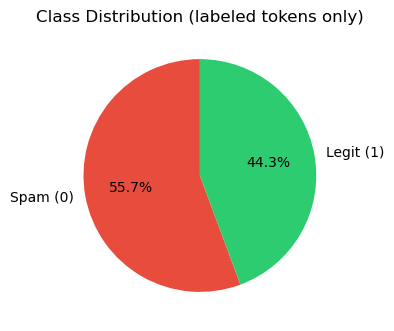

In [6]:
token_features['label'] = token_features.apply(
    lambda r: 1 if r['is_verified'] == 1 else (0 if r['symbol_collision'] == 1 else float('nan')),
    axis=1
)

print('Label distribution (NaN = unlabeled):')
print(token_features['label'].value_counts(dropna=False))
print(f"\nLabeled tokens:   {token_features['label'].notna().sum():,}")
print(f"Unlabeled tokens: {token_features['label'].isna().sum():,}")

# Quick pie chart
fig, ax = plt.subplots(figsize=(4, 4))
labeled_counts = token_features['label'].value_counts()
ax.pie(labeled_counts, labels=['Spam (0)', 'Legit (1)'], autopct='%1.1f%%',
       colors=['#e74c3c', '#2ecc71'], startangle=90)
ax.set_title('Class Distribution (labeled tokens only)')
plt.tight_layout()
plt.show()

## 7. Feature Selection — Drop Leakage Columns

> **Why drop `symbol_collision` and `is_verified`?**  
> These columns *directly construct* the label — a model trained on them would be trivially perfect but useless on unseen tokens where no ground-truth label exists.  
> `asset` is a raw string identifier, not a behavioral feature.

In [7]:
FEATURE_COLS = [
    # Volume / activity
    'n_transfers', 'n_unique_senders', 'n_unique_receivers',
    # Transfer value
    'value_mean', 'value_std', 'value_null_ratio', 'zero_value_ratio', 'unique_values_count',
    # Block distribution
    'n_distinct_blocks', 'block_range',
    # Ratio / derived
    'sender_receiver_ratio', 'transfers_per_block',
    # Concentration
    'top1_sender_share', 'receiver_concentration',
    # Categorical / external
    'category_entropy', 'sender_is_labeled',
]

# Keep only labeled tokens for supervised training
labeled = token_features.dropna(subset=['label']).copy()
X = labeled[FEATURE_COLS].copy()
y = labeled['label'].astype(int)

print(f'Feature matrix X: {X.shape}')
print(f'Target y:')
print(y.value_counts().rename({0: 'Spam (0)', 1: 'Legit (1)'}))

Feature matrix X: (3606, 16)
Target y:
label
Spam (0)     2007
Legit (1)    1599
Name: count, dtype: int64


## 8. Missing Value Imputation

In [8]:
null_counts = X.isnull().sum()
print('Null counts before imputation:')
print(null_counts[null_counts > 0] if null_counts.any() else '  None — all clean.')

# Median imputation — robust to outliers
medians = {}
for col in X.columns:
    if X[col].isnull().any():
        median_val = X[col].median()
        X[col] = X[col].fillna(median_val)
        medians[col] = median_val
        print(f"  Imputed '{col}' → median = {median_val:.4f}")

print(f'\nTotal nulls remaining: {X.isnull().sum().sum()}')

Null counts before imputation:
value_mean    200
value_std     587
dtype: int64
  Imputed 'value_mean' → median = 20879.6169
  Imputed 'value_std' → median = 22573.8131

Total nulls remaining: 0


## 9. Log Transformation of Skewed Features

Apply `log1p(x)` to count and magnitude features. Values are clipped at 0 first to handle any negative artifacts.

Skewness before and after log1p:
                       skew_before  skew_after
n_transfers                  49.14        0.92
n_unique_senders             47.53        1.09
n_unique_receivers           48.12        1.06
value_mean                   60.05        1.04
value_std                    58.68        0.98
sender_receiver_ratio         9.25        2.07
transfers_per_block          42.25        4.29
n_distinct_blocks            11.58        0.93
block_range                   0.15       -0.60
unique_values_count          51.96        0.92


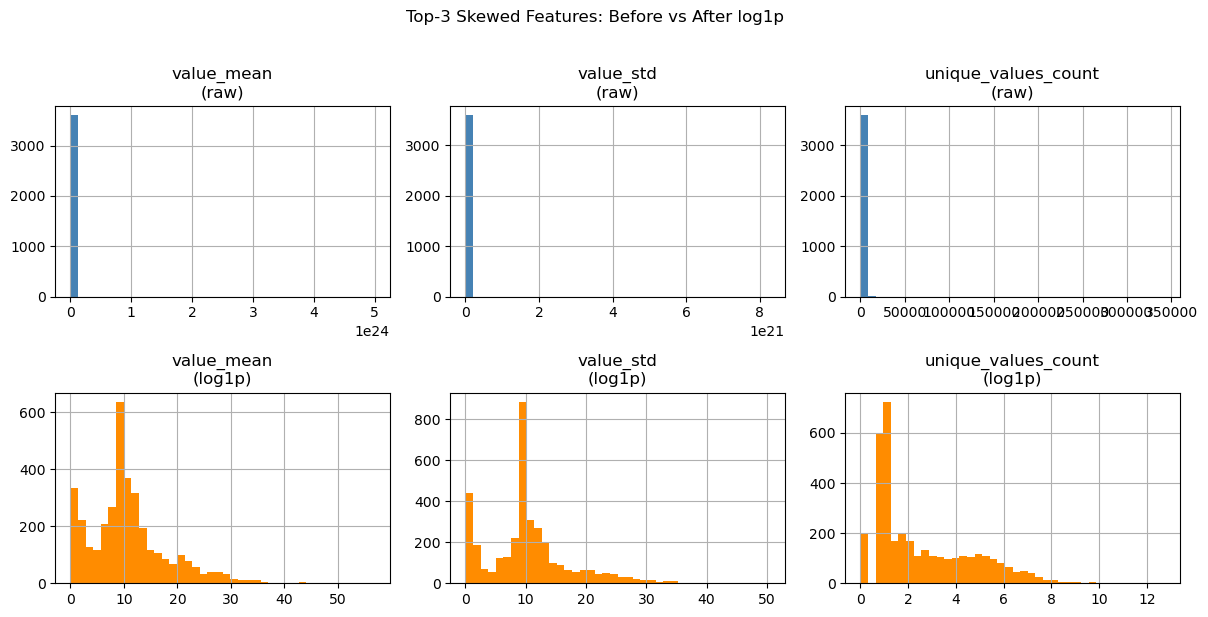

In [9]:
LOG_FEATURES = [
    'n_transfers', 'n_unique_senders', 'n_unique_receivers',
    'value_mean', 'value_std',
    'sender_receiver_ratio', 'transfers_per_block',
    'n_distinct_blocks', 'block_range', 'unique_values_count',
]

X_log = X.copy()
for col in LOG_FEATURES:
    X_log[col] = np.log1p(X_log[col].clip(lower=0))

# Compare skewness before vs after
skew_before = X[LOG_FEATURES].skew().rename('skew_before')
skew_after  = X_log[LOG_FEATURES].skew().rename('skew_after')
skew_df = pd.concat([skew_before, skew_after], axis=1).round(2)
print('Skewness before and after log1p:')
print(skew_df)

# Visual: distribution of top-3 most-skewed features before/after
top3 = skew_before.abs().nlargest(3).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, col in enumerate(top3):
    X[col].hist(bins=40, ax=axes[0, i], color='steelblue', edgecolor='none')
    axes[0, i].set_title(f'{col}\n(raw)')
    X_log[col].hist(bins=40, ax=axes[1, i], color='darkorange', edgecolor='none')
    axes[1, i].set_title(f'{col}\n(log1p)')
plt.suptitle('Top-3 Skewed Features: Before vs After log1p', y=1.02)
plt.tight_layout()
plt.show()

## 10. Stratified Train / Val / Test Split (70 / 15 / 15)

In [10]:
# 70% train | 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_log, y, test_size=0.30, stratify=y, random_state=42
)
# 50/50 split of temp → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

def split_summary(name, X_split, y_split):
    spam  = (y_split == 0).sum()
    legit = (y_split == 1).sum()
    print(f'{name:6s}  rows={len(X_split):4d}  spam={spam:4d} ({spam/len(y_split)*100:.1f}%)  legit={legit:4d} ({legit/len(y_split)*100:.1f}%)')

split_summary('Train', X_train, y_train)
split_summary('Val',   X_val,   y_val)
split_summary('Test',  X_test,  y_test)

Train   rows=2524  spam=1405 (55.7%)  legit=1119 (44.3%)
Val     rows= 541  spam= 301 (55.6%)  legit= 240 (44.4%)
Test    rows= 541  spam= 301 (55.6%)  legit= 240 (44.4%)


## 11. Feature Scaling — RobustScaler

`RobustScaler` centers on the median and scales by the IQR, making it resistant to the outliers common in blockchain data.  
**The scaler is fit on the training set only** and then applied to val and test — no data leakage.

In [11]:
scaler = RobustScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURE_COLS, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=FEATURE_COLS, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURE_COLS, index=X_test.index
)

print('Scaling complete (fit on train only).')
print('\nTrain feature stats after scaling:')
X_train_scaled.describe().round(3)

Scaling complete (fit on train only).

Train feature stats after scaling:


,n_transfers,n_unique_senders,n_unique_receivers,value_mean,value_std,value_null_ratio,zero_value_ratio,unique_values_count,n_distinct_blocks,block_range,sender_receiver_ratio,transfers_per_block,top1_sender_share,receiver_concentration,category_entropy,sender_is_labeled
count,2524.000,2524.000,2524.000,2524.000,2524.000,2524.000,2524.000,2524.000,2524.000,2524.000,2524.000,2524.000,2524.000,2524.000,2524.0,2524.000
mean,0.275,0.299,0.256,0.134,0.078,0.057,0.057,0.259,0.282,-0.338,-0.363,0.124,-0.004,0.165,0.0,-0.191
std,0.681,0.704,0.681,1.024,1.146,0.232,0.232,0.702,0.677,0.535,1.226,0.881,0.722,0.556,0.0,0.393
min,-0.457,-0.410,-0.453,-1.390,-1.622,0.000,0.000,-0.604,-0.358,-1.167,-4.689,-0.722,-1.243,-0.368,0.0,-1.000
25%,-0.228,-0.229,-0.286,-0.489,-0.522,0.000,0.000,-0.234,-0.214,-0.873,-1.000,-0.557,-0.583,-0.368,0.0,0.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000
75%,0.772,0.771,0.714,0.511,0.478,0.000,0.000,0.766,0.786,0.127,0.000,0.443,0.417,0.632,0.0,0.000
max,3.288,4.211,3.851,6.559,6.135,1.000,1.000,3.258,2.668,0.137,11.219,14.953,1.250,1.710,0.0,0.000


## 12. Feature Correlation Heatmap (Post-Processing)

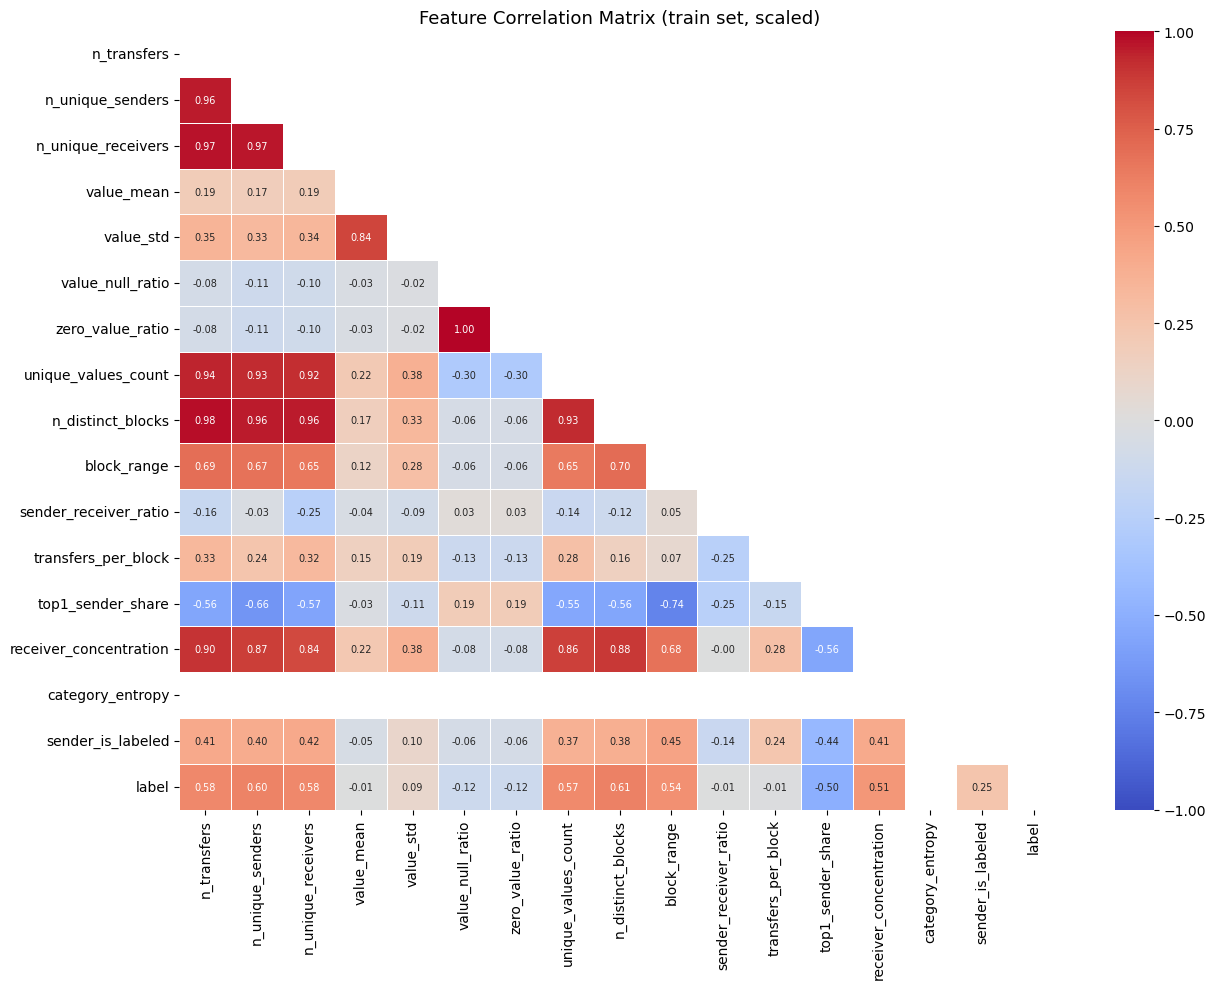

Top 10 features by |correlation| with label:
n_distinct_blocks         0.613
n_unique_senders          0.605
n_unique_receivers        0.583
n_transfers               0.583
unique_values_count       0.575
block_range               0.542
receiver_concentration    0.513
top1_sender_share         0.500
sender_is_labeled         0.246
value_null_ratio          0.120
Name: label, dtype: float64


In [12]:
fig, ax = plt.subplots(figsize=(13, 10))
corr = X_train_scaled.assign(label=y_train.values).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Feature Correlation Matrix (train set, scaled)', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlations with label
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False)
print('Top 10 features by |correlation| with label:')
print(label_corr.head(10).round(3))

## 13. Save Processed Splits

In [13]:
os.makedirs('data/processed', exist_ok=True)

# Scaled splits (for Logistic Regression, SVM, MLP)
X_train_scaled.assign(label=y_train.values).to_parquet('data/processed/train.parquet',       index=False)
X_val_scaled.assign(label=y_val.values).to_parquet('data/processed/val.parquet',             index=False)
X_test_scaled.assign(label=y_test.values).to_parquet('data/processed/test.parquet',          index=False)

# Unscaled splits (for tree-based models: Random Forest, XGBoost, LightGBM)
X_train.assign(label=y_train.values).to_parquet('data/processed/train_unscaled.parquet',     index=False)
X_val.assign(label=y_val.values).to_parquet('data/processed/val_unscaled.parquet',           index=False)
X_test.assign(label=y_test.values).to_parquet('data/processed/test_unscaled.parquet',        index=False)

# Scaler and feature list (needed by modeling notebook to apply same transform on new data)
joblib.dump(scaler,       'data/processed/scaler.joblib')
joblib.dump(FEATURE_COLS, 'data/processed/feature_cols.joblib')

print('Saved to data/processed/:')
for fname in sorted(os.listdir('data/processed')):
    size_kb = os.path.getsize(f'data/processed/{fname}') / 1024
    print(f'  {fname:45s} {size_kb:7.1f} KB')

Saved to data/processed/:
  feature_cols.joblib                               0.3 KB
  scaler.joblib                                     1.3 KB
  test.parquet                                     41.5 KB
  test_unscaled.parquet                            41.4 KB
  train.parquet                                   134.6 KB
  train_unscaled.parquet                          134.4 KB
  val.parquet                                      40.6 KB
  val_unscaled.parquet                             40.5 KB


## Summary

| Step | Details |
|---|---|
| Raw transfers loaded | `transfers_20000000.parquet` |
| Token transfers filtered | `erc20`, `token`, `erc721`, `erc1155`, `specialnft` |
| Total features | 16 (14 from EDA + `block_range`, `unique_values_count`, `zero_value_ratio`, `top1_sender_share`, `receiver_concentration` — minus 3 leakage cols) |
| Leakage cols dropped | `symbol_collision`, `is_verified`, `asset` |
| Labeled tokens | ~3,606 (spam=0: ~2,007 \| legit=1: ~1,599) |
| Split | 70% train / 15% val / 15% test (stratified) |
| Imputation | Median per column |
| Transform | `log1p` on 10 skewed features |
| Scaling | `RobustScaler` (fit on train only) |
| Outputs | `data/processed/` — 6 parquet files + scaler + feature list |

**Next step → `modeling.ipynb`**: train baseline and advanced classifiers on these splits.